# 7. Modelado Baseline Multi-Versión — Screening Preanestésico

**Objetivo**: comparar fácilmente diferentes estrategias de construcción de target.

## Flujo
1. Cargar datasets mergeados por versión
2. Cargar variables seleccionadas por versión
3. Entrenar modelos baseline por versión
4. Comparar métricas (incluye **Accuracy**, ROC-AUC, F1, F2, Recall, Precision)

## 1. Setup

In [21]:
import pandas as pd
import numpy as np
import warnings

import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from utils.version_config import ACTIVE_VERSIONS, VERSION_HISTORY
from utils.multi_version import (
    run_modeling_pipeline,
    run_hyperparameter_experiments,
    run_pre_post_linkage_analysis,
 )
import utils.modeling as mod
import utils.visualization as viz

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("../data")
MERGED_DIR = DATA_DIR / "merged_versions"
FEATURES_VERSIONED_DIR = Path("../features/versioned")
MODELING_RESULTS_DIR = Path("../features/modeling_versions")
MODELING_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Carga de Artefactos por Versión

In [5]:
modeling_artifacts = run_modeling_pipeline(
    merged_dir=MERGED_DIR,
    features_versioned_dir=FEATURES_VERSIONED_DIR,
    output_dir=MODELING_RESULTS_DIR,
    random_state=RANDOM_STATE,
    active_versions=ACTIVE_VERSIONS,
    balance_mode="train_only",  # none | train_only | train_test
    threshold_metric="balanced_accuracy",  # f1 | f2 | balanced_accuracy
    threshold_prevalence_tolerance=0.5,
    val_size=0.2,
    test_size=0.2,
)

print(f"Versiones en común: {len(modeling_artifacts['experiment_registry'])}")
print(f"Estrategias evaluadas: {len(modeling_artifacts['results'])}")
print("Split aplicado: train/validation/test (threshold optimizado en validation, métricas en test)")
print("Balanceo aplicado: train_only (solo entrenamiento balanceado)")
print("Threshold aplicado: balanced_accuracy con restricción de prevalencia en validation")

Sanitización de Features realizada:
   - Originales: 80
   - Mantenidas: 80
   - Eliminadas (constantes): 0


[09:42:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:42:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:42:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:42:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:42:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Sanitización de Features realizada:
   - Originales: 80
   - Mantenidas: 80
   - Eliminadas (constantes): 0


[09:44:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:44:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:44:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:44:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:44:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Sanitización de Features realizada:
   - Originales: 80
   - Mantenidas: 80
   - Eliminadas (constantes): 0


[09:46:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:46:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:46:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:46:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:46:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Versiones en común: 3
Estrategias evaluadas: 30
Split aplicado: train/validation/test (threshold optimizado en validation, métricas en test)
Balanceo aplicado: train_only (solo entrenamiento balanceado)
Threshold aplicado: balanced_accuracy con restricción de prevalencia en validation


In [6]:
print(f"Versiones activas: {ACTIVE_VERSIONS}")
display(pd.DataFrame(VERSION_HISTORY))

experiment_registry = modeling_artifacts["experiment_registry"]
ignored_versions = modeling_artifacts.get("ignored_versions", [])

if ignored_versions:
    print("Versiones ignoradas (no activas):", ignored_versions)

experiment_registry

Versiones activas: ['v1', 'v2', 'v3_sin_liquidos']


,version,threshold,flags_to_use,excluded_flags,apply_cancel_non_medico_rule,export_name,description,executed_on,notes
0,v1,1,RELEVANT_FLAGS,EXCLUDED_FLAGS,True,OPERA_POS_v1.xlsx,Sin agregación (>=1 flag),2026-02-28,Baseline histórico
1,v2,2,RELEVANT_FLAGS,EXCLUDED_FLAGS,True,OPERA_POS_v2.xlsx,Con agregación (>=2 flags),2026-02-28,Baseline histórico
2,v3_sin_liquidos,1,RELEVANT_FLAGS - flag_liquidos,EXCLUDED_FLAGS,True,OPERA_POS_v3_sin_liquidos.xlsx,Sin flag_liquidos (>=1 flag),2026-02-28,Sensibilidad clínica


,version,dataset_path,features_path
0,v1,../data/merged_versions/OPERA_COMPLETO_v1.xlsx,../features/versioned/v1_selected_features_lis...
1,v2,../data/merged_versions/OPERA_COMPLETO_v2.xlsx,../features/versioned/v2_selected_features_lis...
2,v3_sin_liquidos,../data/merged_versions/OPERA_COMPLETO_v3_sin_...,../features/versioned/v3_sin_liquidos_selected...


In [7]:
experiment_registry

,version,dataset_path,features_path
0,v1,../data/merged_versions/OPERA_COMPLETO_v1.xlsx,../features/versioned/v1_selected_features_lis...
1,v2,../data/merged_versions/OPERA_COMPLETO_v2.xlsx,../features/versioned/v2_selected_features_lis...
2,v3_sin_liquidos,../data/merged_versions/OPERA_COMPLETO_v3_sin_...,../features/versioned/v3_sin_liquidos_selected...


## 3. Preparación de Datos por Versión

In [8]:
df_results = modeling_artifacts["results"]
summary_by_version = modeling_artifacts["summary_by_version"]
pivot_auc = modeling_artifacts["pivot_auc"]
pivot_f2 = modeling_artifacts["pivot_f2"]
pivot_acc = modeling_artifacts["pivot_accuracy"]
predictions_by_version = modeling_artifacts["predictions_by_version"]
y_test_by_version = modeling_artifacts["y_test_by_version"]
best_version = modeling_artifacts["best_version"]
best_model = modeling_artifacts["best_model"]

print(f"Mejor versión: {best_version}")
print(f"Mejor modelo: {best_model}")

Mejor versión: v2
Mejor modelo: Stacking Ensemble


## 4. Entrenamiento Baseline por Versión

In [9]:
print(f"\nTotal estrategias evaluadas: {len(df_results)}")
df_results.head(20)


Total estrategias evaluadas: 30


,Version,Model,N_Train,N_Val,N_Test,N_Features,Balance_Mode,Train_Pos_Rate_Original,Val_Pos_Rate_Original,Test_Pos_Rate_Original,Train_Pos_Rate_Used,Val_Pos_Rate_Used,Test_Pos_Rate_Used,Threshold_Min_Pos_Rate,Threshold_Max_Pos_Rate,Accuracy,Recall,Precision,F1,F2,ROC-AUC,Brier,Threshold,Threshold_Objective_Metric,Threshold_Objective_Score,F2_Validation_OptThreshold
0,v2,Stacking Ensemble,6418,4678,4678,80,train_only,0.228708,0.228730,0.228730,0.5,0.228730,0.228730,0.114365,0.343095,0.696665,0.569159,0.388641,0.461889,0.520780,0.723676,0.216979,0.57,balanced_accuracy,0.661068,0.527725
1,v2,Voting Ensemble,6418,4678,4678,80,train_only,0.228708,0.228730,0.228730,0.5,0.228730,0.228730,0.114365,0.343095,0.691107,0.570093,0.382445,0.457786,0.519149,0.721493,0.217964,0.57,balanced_accuracy,0.654072,0.521299
2,v2,Gradient Boosting,6418,4678,4678,80,train_only,0.228708,0.228730,0.228730,0.5,0.228730,0.228730,0.114365,0.343095,0.687901,0.549533,0.375479,0.446131,0.502908,0.718425,0.215666,0.55,balanced_accuracy,0.658757,0.534014
3,v2,Random Forest,6418,4678,4678,80,train_only,0.228708,0.228730,0.228730,0.5,0.228730,0.228730,0.114365,0.343095,0.703506,0.515888,0.388459,0.443196,0.484126,0.717786,0.219657,0.55,balanced_accuracy,0.652525,0.505963
4,v2,Extra Trees,6418,4678,4678,80,train_only,0.228708,0.228730,0.228730,0.5,0.228730,0.228730,0.114365,0.343095,0.703078,0.523364,0.389159,0.446393,0.489596,0.716768,0.217288,0.55,balanced_accuracy,0.652835,0.509081
5,v2,XGBoost,6418,4678,4678,80,train_only,0.228708,0.228730,0.228730,0.5,0.228730,0.228730,0.114365,0.343095,0.692817,0.552336,0.381536,0.451317,0.506948,0.712529,0.235794,0.62,balanced_accuracy,0.638818,0.502650
6,v2,HistGradientBoosting,6418,4678,4678,80,train_only,0.228708,0.228730,0.228730,0.5,0.228730,0.228730,0.114365,0.343095,0.686191,0.546729,0.373087,0.443518,0.500171,0.706310,0.237656,0.61,balanced_accuracy,0.637520,0.501367
7,v3_sin_liquidos,Stacking Ensemble,13866,4678,4678,80,train_only,0.505880,0.505772,0.505772,0.5,0.505772,0.505772,0.252886,0.758658,0.632535,0.535080,0.671618,0.595625,0.557758,0.703739,0.216595,0.55,balanced_accuracy,0.620615,0.545527
8,v3_sin_liquidos,Random Forest,13866,4678,4678,80,train_only,0.505880,0.505772,0.505772,0.5,0.505772,0.505772,0.252886,0.758658,0.634673,0.644970,0.637161,0.641042,0.643393,0.699851,0.219719,0.51,balanced_accuracy,0.619312,0.632363
9,v3_sin_liquidos,Voting Ensemble,13866,4678,4678,80,train_only,0.505880,0.505772,0.505772,0.5,0.505772,0.505772,0.252886,0.758658,0.633818,0.597633,0.650115,0.622770,0.607441,0.698832,0.218655,0.52,balanced_accuracy,0.621161,0.611106


## 5. Visualización por Versión (todas las estrategias)

MATRICES DE CONFUSIÓN POR VERSIÓN (TODOS LOS MODELOS)

Versión: v1


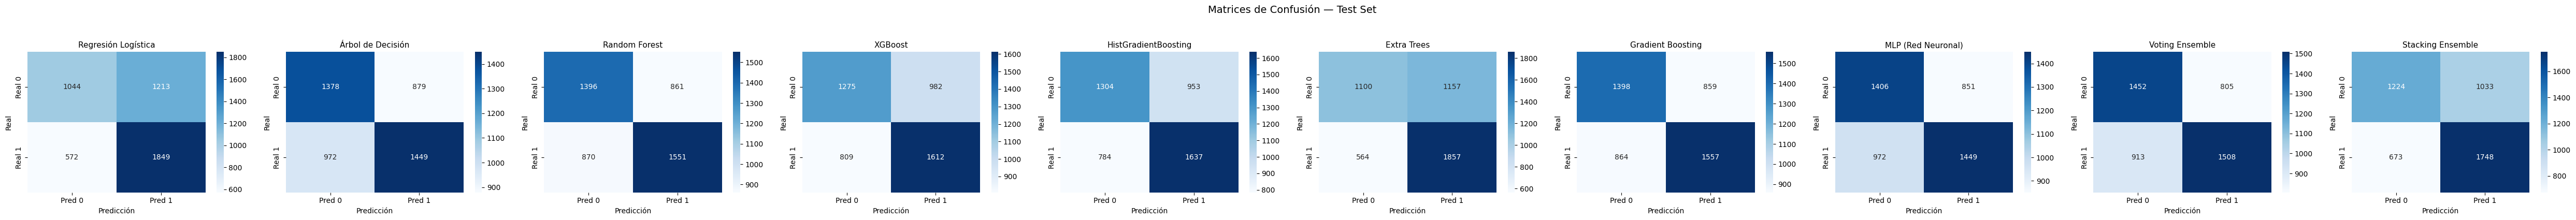


Versión: v2


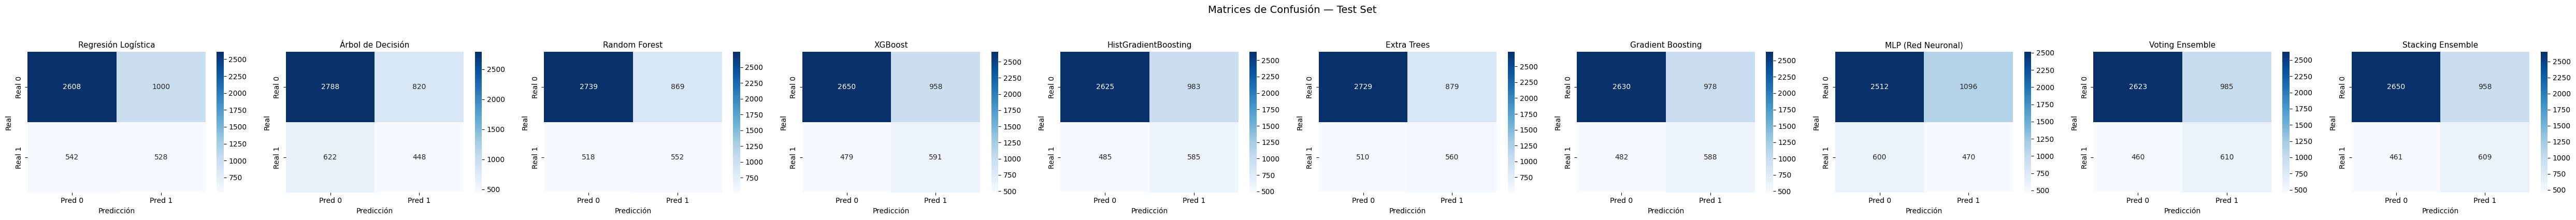


Versión: v3_sin_liquidos


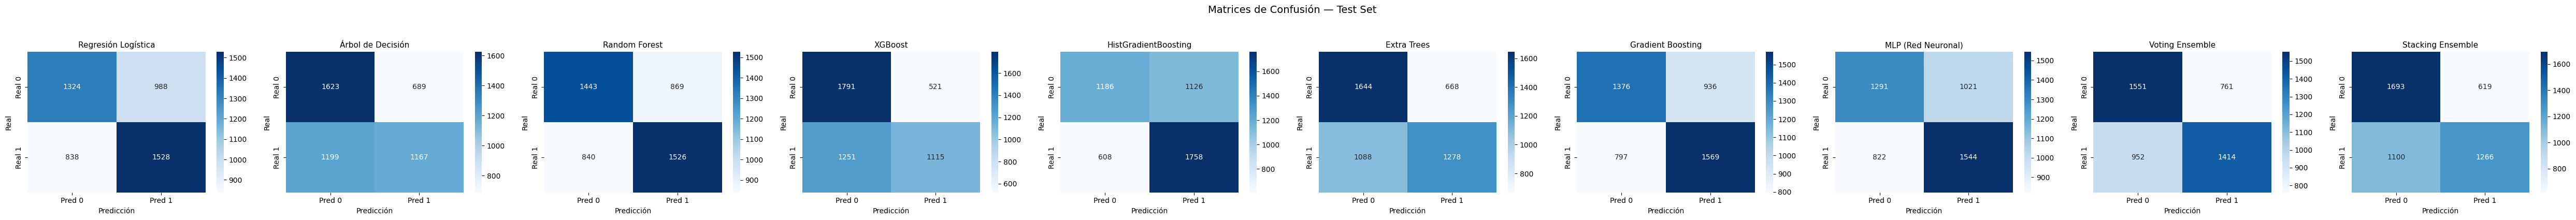

In [10]:
print("=" * 90)
print("MATRICES DE CONFUSIÓN POR VERSIÓN (TODOS LOS MODELOS)")
print("=" * 90)

for version in sorted(predictions_by_version.keys()):
    print(f"\nVersión: {version}")
    viz.plot_confusion_matrices(
        predictions_by_version[version],
        y_test_by_version[version],
        save_path=f"../matrices_confusion_{version}.png",
    )

CURVAS ROC/PR POR VERSIÓN (TODOS LOS MODELOS)

Versión: v1


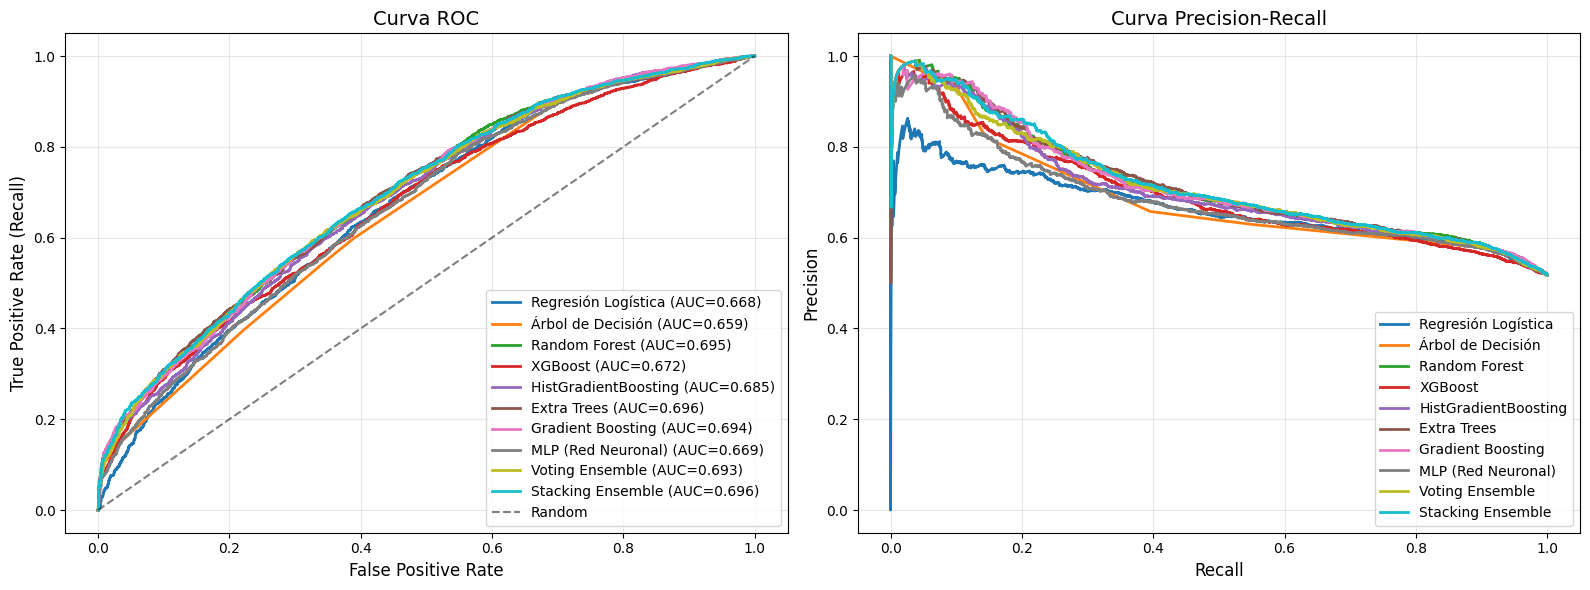


Versión: v2


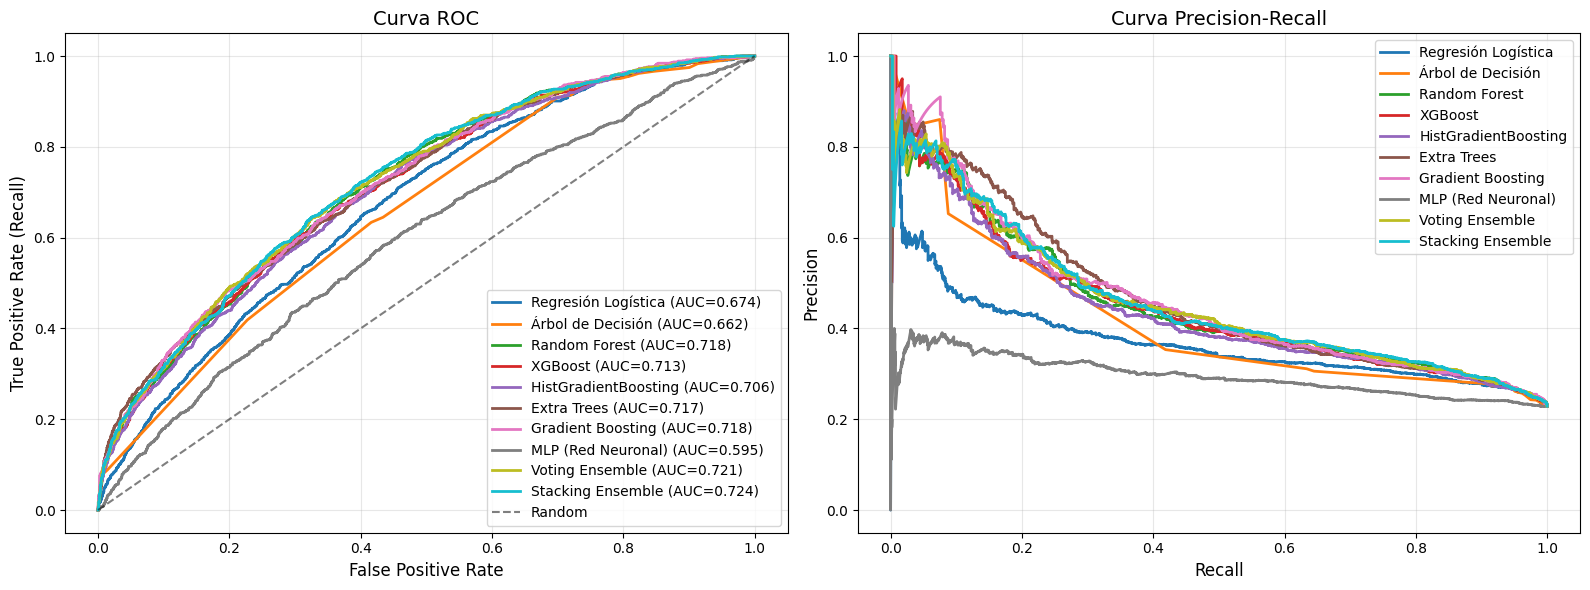


Versión: v3_sin_liquidos


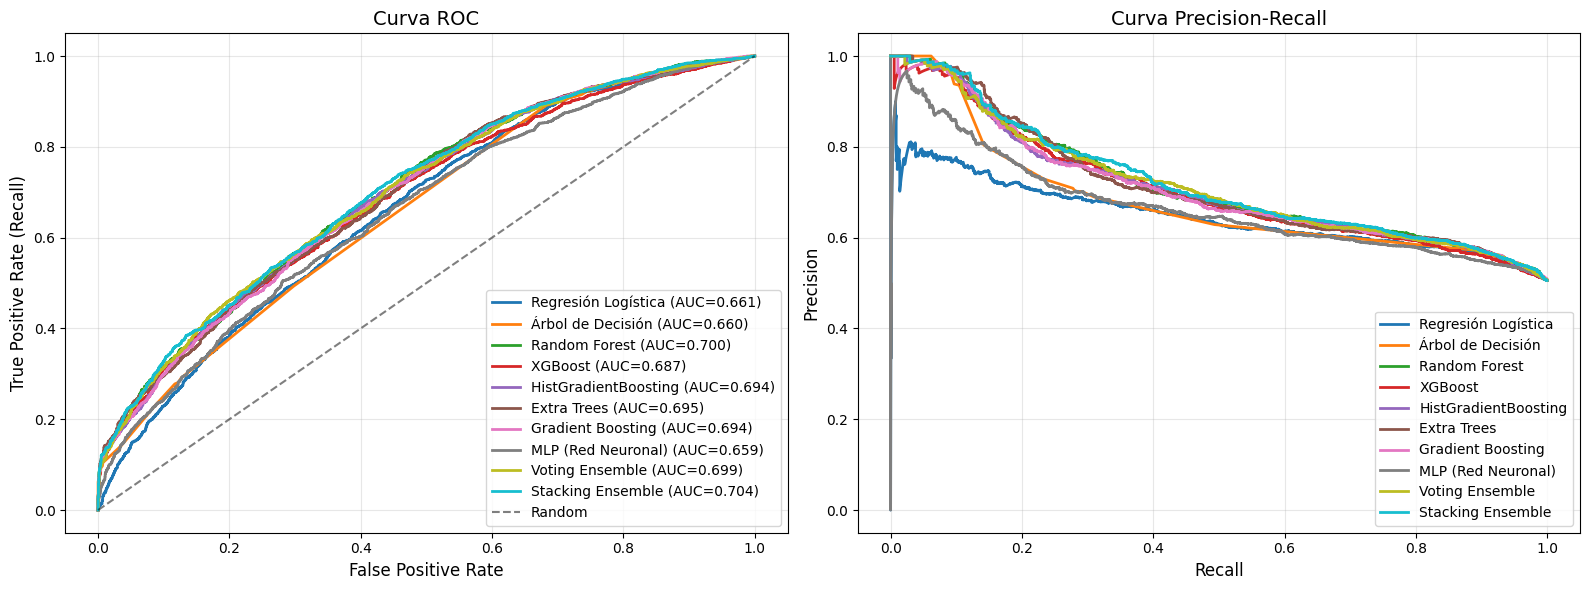

In [11]:
print("=" * 90)
print("CURVAS ROC/PR POR VERSIÓN (TODOS LOS MODELOS)")
print("=" * 90)

for version in sorted(predictions_by_version.keys()):
    print(f"\nVersión: {version}")
    viz.plot_roc_pr_curves(
        predictions_by_version[version],
        y_test_by_version[version],
        save_path=f"../curvas_roc_pr_{version}.png",
    )

## 6. Comparación Multi-Versión (Baseline + Balanceo de Clases)

In [12]:
summary_by_version = (
    df_results.sort_values(["Version", "ROC-AUC", "F2", "Accuracy"], ascending=[True, False, False, False])
    .groupby("Version", as_index=False)
    .first()
)

summary_by_version[[
    "Version",
    "Model",
    "Balance_Mode",
    "N_Train", "N_Val", "N_Test",
    "Train_Pos_Rate_Original",
    "Val_Pos_Rate_Original",
    "Test_Pos_Rate_Original",
    "Train_Pos_Rate_Used",
    "Val_Pos_Rate_Used",
    "Test_Pos_Rate_Used",
    "F2_Validation_OptThreshold",
    "Accuracy", "Recall", "Precision", "F1", "F2", "ROC-AUC", "Threshold", "N_Features",
]]

,Version,Model,Balance_Mode,N_Train,N_Val,N_Test,Train_Pos_Rate_Original,Val_Pos_Rate_Original,Test_Pos_Rate_Original,Train_Pos_Rate_Used,Val_Pos_Rate_Used,Test_Pos_Rate_Used,F2_Validation_OptThreshold,Accuracy,Recall,Precision,F1,F2,ROC-AUC,Threshold,N_Features
0,v1,Stacking Ensemble,train_only,13540,4678,4678,0.517497,0.517529,0.517529,0.5,0.517529,0.517529,0.695383,0.635314,0.722016,0.628551,0.672049,0.701163,0.696336,0.48,80
1,v2,Stacking Ensemble,train_only,6418,4678,4678,0.228708,0.228730,0.228730,0.5,0.228730,0.228730,0.527725,0.696665,0.569159,0.388641,0.461889,0.520780,0.723676,0.57,80
2,v3_sin_liquidos,Stacking Ensemble,train_only,13866,4678,4678,0.505880,0.505772,0.505772,0.5,0.505772,0.505772,0.545527,0.632535,0.535080,0.671618,0.595625,0.557758,0.703739,0.55,80


In [13]:
pivot_auc = df_results.pivot(index="Version", columns="Model", values="ROC-AUC")
pivot_f2 = df_results.pivot(index="Version", columns="Model", values="F2")
pivot_acc = df_results.pivot(index="Version", columns="Model", values="Accuracy")

print("ROC-AUC por versión/modelo")
display(pivot_auc)

print("F2 por versión/modelo")
display(pivot_f2)

print("Accuracy por versión/modelo")
display(pivot_acc)

ROC-AUC por versión/modelo


Model,Extra Trees,Gradient Boosting,HistGradientBoosting,MLP (Red Neuronal),Random Forest,Regresión Logística,Stacking Ensemble,Voting Ensemble,XGBoost,Árbol de Decisión
Version,,,,,,,,,,
v1,0.695643,0.693773,0.685429,0.669215,0.694889,0.667905,0.696336,0.692767,0.671797,0.659243
v2,0.716768,0.718425,0.706310,0.594894,0.717786,0.674185,0.723676,0.721493,0.712529,0.661522
v3_sin_liquidos,0.694553,0.694300,0.694395,0.658549,0.699851,0.660829,0.703739,0.698832,0.686837,0.659645


F2 por versión/modelo


Model,Extra Trees,Gradient Boosting,HistGradientBoosting,MLP (Red Neuronal),Random Forest,Regresión Logística,Stacking Ensemble,Voting Ensemble,XGBoost,Árbol de Decisión
Version,,,,,,,,,,
v1,0.731218,0.643388,0.666857,0.604556,0.641121,0.725326,0.701163,0.628490,0.656459,0.603147
v2,0.489596,0.502908,0.500171,0.401984,0.484126,0.454545,0.520780,0.519149,0.506948,0.403749
v3_sin_liquidos,0.560035,0.655443,0.711856,0.641782,0.643393,0.637730,0.557758,0.607441,0.502252,0.515459


Accuracy por versión/modelo


Model,Extra Trees,Gradient Boosting,HistGradientBoosting,MLP (Red Neuronal),Random Forest,Regresión Logística,Stacking Ensemble,Voting Ensemble,XGBoost,Árbol de Decisión
Version,,,,,,,,,,
v1,0.632108,0.631680,0.628687,0.610304,0.629970,0.618427,0.635314,0.632749,0.617144,0.604318
v2,0.703078,0.687901,0.686191,0.637452,0.703506,0.670372,0.696665,0.691107,0.692817,0.691749
v3_sin_liquidos,0.624626,0.629543,0.629329,0.606028,0.634673,0.609662,0.632535,0.633818,0.621206,0.596409


OPTIMIZACIÓN DE UMBRAL EN VALIDATION (F2, SOLO ANÁLISIS)


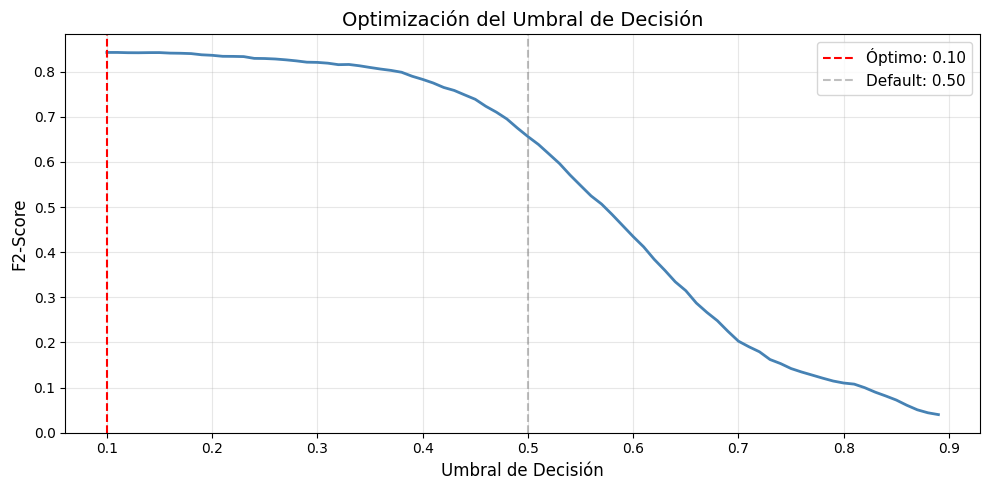

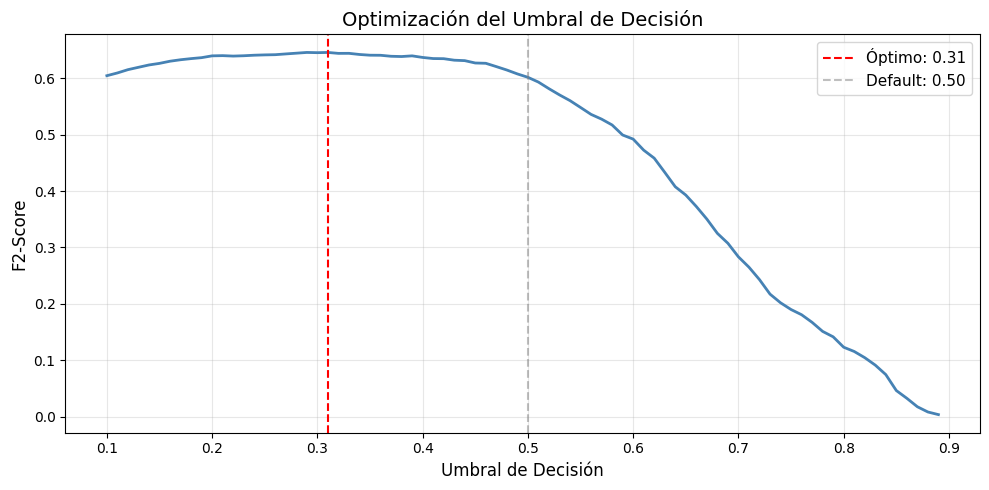

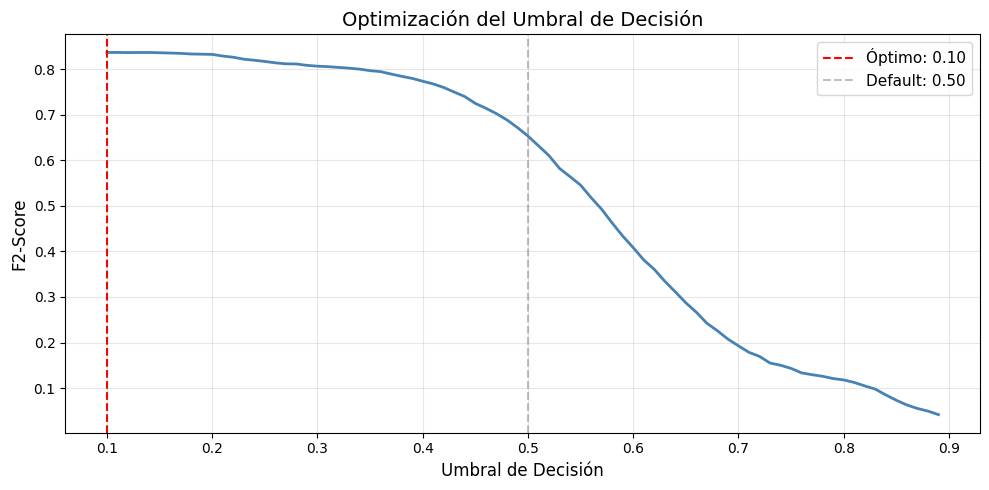

,Version,Model,Threshold_Optimo_F2_Validation,F2_Optimo_Validation
0,v1,Stacking Ensemble,0.10,0.8428
1,v2,Stacking Ensemble,0.31,0.6460
2,v3_sin_liquidos,Stacking Ensemble,0.10,0.8365


In [14]:
print("=" * 90)
print("OPTIMIZACIÓN DE UMBRAL EN VALIDATION (F2, SOLO ANÁLISIS)")
print("=" * 90)

y_val_by_version = modeling_artifacts["y_val_by_version"]
threshold_summary_rows = []

for version in sorted(predictions_by_version.keys()):
    version_rows = df_results[df_results["Version"] == version].sort_values(
        ["ROC-AUC", "F2", "Accuracy"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    if version_rows.empty:
        continue

    version_model = version_rows.iloc[0]["Model"]
    y_proba_val = predictions_by_version[version][version_model]["y_val_proba"]

    opt_thresh, opt_f2, thresholds, f2_scores = mod.find_optimal_threshold(
        y_val_by_version[version],
        y_proba_val,
        metric="f2",
    )

    viz.plot_threshold_optimization(
        thresholds,
        f2_scores,
        opt_thresh,
        save_path=f"../umbral_optimo_validation_{version}_{version_model.replace(' ', '_')}.png",
    )

    threshold_summary_rows.append(
        {
            "Version": version,
            "Model": version_model,
            "Threshold_Optimo_F2_Validation": round(float(opt_thresh), 4),
            "F2_Optimo_Validation": round(float(opt_f2), 4),
        }
    )

df_threshold_summary = pd.DataFrame(threshold_summary_rows).sort_values("Version").reset_index(drop=True)
df_threshold_summary

## 7. Explicabilidad por Versión (global y casos)

In [15]:
explainability_registry = modeling_artifacts["explainability_registry"]
global_expl = modeling_artifacts["explainability_global_by_version"]
case_expl = modeling_artifacts["explainability_cases_by_version"]

print("Registro de explicabilidad por versión:")
display(explainability_registry)

for version in sorted(global_expl.keys()):
    print(f"\n{'='*90}")
    print(f"EXPLICABILIDAD GLOBAL — Versión: {version}")
    print(f"{'='*90}")
    display(global_expl[version].head(20))

    print(f"\nCasos de auditoría clínica — Versión: {version}")
    display(case_expl[version].head(20))

print("\nArchivos exportados:")
for key, value in modeling_artifacts["output_paths"].items():
    print(f"- {key}: {value}")

Registro de explicabilidad por versión:


,Version,Best_Model_For_Explainability,Global_Explainability_Path,Case_Review_Path
0,v1,Stacking Ensemble,../features/modeling_versions/explainability_g...,../features/modeling_versions/explainability_c...
1,v2,Stacking Ensemble,../features/modeling_versions/explainability_g...,../features/modeling_versions/explainability_c...
2,v3_sin_liquidos,Stacking Ensemble,../features/modeling_versions/explainability_g...,../features/modeling_versions/explainability_c...



EXPLICABILIDAD GLOBAL — Versión: v1


,Feature,Importance,Source
0,Tipo de anestesia propuesta_sedacion,0.064814,permutation_importance
1,Tipo de anestesia propuesta_raquidea,0.024952,permutation_importance
2,Tipo de anestesia propuesta_peridural,0.009302,permutation_importance
3,Examen_Hemoglobina(g/dl),0.008503,permutation_importance
4,score_proc_medium_severity,0.005050,permutation_importance
5,score_proc_critical,0.004488,permutation_importance
6,Sexo_encoded,0.004007,permutation_importance
7,score_proc_high_severity,0.003908,permutation_importance
8,score_proc_low_severity,0.003650,permutation_importance
9,Tipo de anestesia propuesta_general,0.003632,permutation_importance



Casos de auditoría clínica — Versión: v1


...


EXPLICABILIDAD GLOBAL — Versión: v3_sin_liquidos


,Feature,Importance,Source
0,Tipo de anestesia propuesta_sedacion,0.068651,permutation_importance
1,Tipo de anestesia propuesta_raquidea,0.016409,permutation_importance
2,Tipo de anestesia propuesta_peridural,0.008675,permutation_importance
3,Examen_Hemoglobina(g/dl),0.007394,permutation_importance
4,score_proc_low_severity,0.006658,permutation_importance
5,score_proc_medium_severity,0.003998,permutation_importance
6,score_proc_high_severity,0.003889,permutation_importance
7,Tipo de anestesia propuesta_local,0.003590,permutation_importance
8,score_proc_critical,0.003509,permutation_importance
9,Sexo_encoded,0.003479,permutation_importance



Casos de auditoría clínica — Versión: v3_sin_liquidos


,case_index,case_type,y_true,y_pred,y_proba,reason
0,13936,FN,1,0,0.549664,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
1,5802,FN,1,0,0.549289,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
2,8152,FN,1,0,0.549287,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
3,9151,FN,1,0,0.549201,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
4,16848,FN,1,0,0.548308,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
5,3249,FN,1,0,0.548103,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
6,21539,FN,1,0,0.547400,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
7,17560,FN,1,0,0.547331,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
8,2876,FP,0,1,0.550046,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
9,20831,FP,0,1,0.550079,Tipo de anestesia propuesta_sedacion=0.0 | Tip...



Archivos exportados:
- results: ../features/modeling_versions/baseline_results_by_version.csv
- summary: ../features/modeling_versions/best_model_by_version.csv
- pivot_auc: ../features/modeling_versions/pivot_auc.csv
- pivot_f2: ../features/modeling_versions/pivot_f2.csv
- pivot_accuracy: ../features/modeling_versions/pivot_accuracy.csv
- explainability_registry: ../features/modeling_versions/explainability_registry.csv


In [16]:
top10_global = df_results.head(10).copy()
top10_global[["Version", "Model", "Accuracy", "F2", "ROC-AUC", "Recall", "Precision", "Threshold"]]

,Version,Model,Accuracy,F2,ROC-AUC,Recall,Precision,Threshold
0,v2,Stacking Ensemble,0.696665,0.520780,0.723676,0.569159,0.388641,0.57
1,v2,Voting Ensemble,0.691107,0.519149,0.721493,0.570093,0.382445,0.57
2,v2,Gradient Boosting,0.687901,0.502908,0.718425,0.549533,0.375479,0.55
3,v2,Random Forest,0.703506,0.484126,0.717786,0.515888,0.388459,0.55
4,v2,Extra Trees,0.703078,0.489596,0.716768,0.523364,0.389159,0.55
5,v2,XGBoost,0.692817,0.506948,0.712529,0.552336,0.381536,0.62
6,v2,HistGradientBoosting,0.686191,0.500171,0.706310,0.546729,0.373087,0.61
7,v3_sin_liquidos,Stacking Ensemble,0.632535,0.557758,0.703739,0.535080,0.671618,0.55
8,v3_sin_liquidos,Random Forest,0.634673,0.643393,0.699851,0.644970,0.637161,0.51
9,v3_sin_liquidos,Voting Ensemble,0.633818,0.607441,0.698832,0.597633,0.650115,0.52


## 8. Experimentos de entrenamiento (tuning + combinaciones)

In [ ]:
hyper_artifacts = run_hyperparameter_experiments(
    merged_dir=MERGED_DIR,
    features_versioned_dir=FEATURES_VERSIONED_DIR,
    output_dir=MODELING_RESULTS_DIR,
    random_state=RANDOM_STATE,
    active_versions=ACTIVE_VERSIONS,
    balance_mode="train_only",
    val_size=0.2,
    test_size=0.2,
    threshold_metric="balanced_accuracy",
    threshold_prevalence_tolerance=0.5,
    tune_models=["XGBoost", "Random Forest", "HistGradientBoosting", "Regresión Logística"],
    optimize_metric="roc_auc",
    n_trials=15,
    feature_subset_fractions=(1.0, 0.75, 0.5),
)

df_hyper = hyper_artifacts["experiments"]
df_hyper_best = hyper_artifacts["best_by_version"]

print("Mejores resultados de tuning por versión:")
display(
    df_hyper_best[[
        "Version", "Model", "Feature_Subset", "N_Features",
        "Validation_ROC-AUC", "Validation_F2",
        "Test_ROC-AUC", "Test_F2", "Test_Accuracy", "Test_Recall", "Test_Precision", "Test_Threshold",
        "Tuning_Best_CV_Score", "Tuning_N_Trials",
    ]]
)

print("Top 20 experimentos de tuning:")
display(
    df_hyper[[
        "Version", "Model", "Feature_Subset", "N_Features",
        "Test_ROC-AUC", "Test_F2", "Test_Accuracy", "Test_Recall", "Test_Precision", "Test_Threshold",
        "Validation_ROC-AUC", "Validation_F2", "Tuning_Best_CV_Score", "Best_Params",
    ]].head(20)
)

print("Comparación directa Baseline vs Tuning (mejor por versión):")
baseline_best = (
    df_results.sort_values(["Version", "ROC-AUC", "F2"], ascending=[True, False, False])
    .groupby("Version", as_index=False)
    .first()
    .rename(columns={
        "Model": "Baseline_Model",
        "ROC-AUC": "Baseline_ROC-AUC",
        "F2": "Baseline_F2",
        "Accuracy": "Baseline_Accuracy",
    })
)

comparison = baseline_best.merge(
    df_hyper_best[["Version", "Model", "Feature_Subset", "Test_ROC-AUC", "Test_F2", "Test_Accuracy"]],
    on="Version",
    how="left",
).rename(columns={
    "Model": "Tuned_Model",
    "Feature_Subset": "Tuned_Feature_Subset",
    "Test_ROC-AUC": "Tuned_ROC-AUC",
    "Test_F2": "Tuned_F2",
    "Test_Accuracy": "Tuned_Accuracy",
})

comparison["Delta_ROC-AUC"] = comparison["Tuned_ROC-AUC"] - comparison["Baseline_ROC-AUC"]
comparison["Delta_F2"] = comparison["Tuned_F2"] - comparison["Baseline_F2"]
comparison["Delta_Accuracy"] = comparison["Tuned_Accuracy"] - comparison["Baseline_Accuracy"]

display(comparison.sort_values("Delta_ROC-AUC", ascending=False))

print("Comparación visual: top n modelos por métrica")
import matplotlib.pyplot as plt

n_top_models = 10
metric_cols = [
    "Test_ROC-AUC",
    "Test_F2",
    "Test_Accuracy",
    "Test_Recall",
    "Test_Precision",
]

df_plot = df_hyper.copy()
df_plot["Experiment_Label"] = (
    "V" + df_plot["Version"].astype(str)
    + " | " + df_plot["Model"].astype(str)
    + " | " + df_plot["Feature_Subset"].astype(str)
)

n_metrics = len(metric_cols)
fig, axes = plt.subplots(nrows=n_metrics, ncols=1, figsize=(14, 4 * n_metrics))

if n_metrics == 1:
    axes = [axes]

for ax, metric in zip(axes, metric_cols):
    top_metric = (
        df_plot.sort_values(metric, ascending=False)
        .head(n_top_models)
        .sort_values(metric, ascending=True)
    )
    ax.barh(top_metric["Experiment_Label"], top_metric[metric])
    ax.set_title(f"Top {n_top_models} modelos por {metric}")
    ax.set_xlabel(metric)
    ax.set_ylabel("Versión | Modelo | Subset")

plt.tight_layout()
plt.show()

print("Archivos de tuning exportados:")
for key, value in hyper_artifacts["output_paths"].items():
    print(f"- {key}: {value}")

Sanitización de Features realizada:
   - Originales: 80
   - Mantenidas: 80
   - Eliminadas (constantes): 0
Optimizing hyperparameters for: XGBoost (Target: roc_auc)
Optimizing hyperparameters for: Random Forest (Target: roc_auc)
Optimizing hyperparameters for: HistGradientBoosting (Target: roc_auc)
Optimizing hyperparameters for: Regresión Logística (Target: roc_auc)
Optimizing hyperparameters for: XGBoost (Target: roc_auc)
Optimizing hyperparameters for: Random Forest (Target: roc_auc)
Optimizing hyperparameters for: HistGradientBoosting (Target: roc_auc)
Optimizing hyperparameters for: Regresión Logística (Target: roc_auc)
Optimizing hyperparameters for: XGBoost (Target: roc_auc)
Optimizing hyperparameters for: Random Forest (Target: roc_auc)
Optimizing hyperparameters for: HistGradientBoosting (Target: roc_auc)
Optimizing hyperparameters for: Regresión Logística (Target: roc_auc)
Sanitización de Features realizada:
   - Originales: 80
   - Mantenidas: 80
   - Eliminadas (constantes

,Version,Model,Feature_Subset,N_Features,Validation_ROC-AUC,Validation_F2,Test_ROC-AUC,Test_F2,Test_Accuracy,Test_Recall,Test_Precision,Test_Threshold,Tuning_Best_CV_Score,Tuning_N_Trials
0,v1,XGBoost,top_100pct,80,0.677176,0.648429,0.700046,0.649399,0.631253,0.651384,0.641579,0.50,0.690027,15
1,v2,XGBoost,top_100pct,80,0.735572,0.521159,0.722597,0.496632,0.694528,0.537383,0.381047,0.56,0.713329,15
2,v3_sin_liquidos,Random Forest,top_100pct,80,0.673338,0.624157,0.702913,0.637010,0.635528,0.636095,0.640698,0.51,0.690791,15


Top 20 experimentos de tuning:


,Version,Model,Feature_Subset,N_Features,Test_ROC-AUC,Test_F2,Test_Accuracy,Test_Recall,Test_Precision,Test_Threshold,Validation_ROC-AUC,Validation_F2,Tuning_Best_CV_Score,Best_Params
0,v2,XGBoost,top_100pct,80,0.722597,0.496632,0.694528,0.537383,0.381047,0.56,0.735572,0.521159,0.713329,"{""max_depth"": 4, ""learning_rate"": 0.0197714843..."
1,v2,Random Forest,top_100pct,80,0.720280,0.510099,0.692176,0.557009,0.381562,0.54,0.738825,0.529191,0.710979,"{""n_estimators"": 1000, ""max_depth"": 20, ""min_s..."
2,v2,HistGradientBoosting,top_100pct,80,0.719368,0.479561,0.709919,0.506542,0.395332,0.58,0.730702,0.494428,0.707860,"{""max_iter"": 500, ""max_depth"": 6, ""learning_ra..."
3,v2,XGBoost,top_75pct,60,0.715828,0.485967,0.692176,0.524299,0.376005,0.56,0.734977,0.511019,0.710348,"{""max_depth"": 4, ""learning_rate"": 0.0171731364..."
4,v2,Random Forest,top_75pct,60,0.714840,0.496991,0.690252,0.540187,0.376547,0.54,0.733662,0.522298,0.709763,"{""n_estimators"": 1000, ""max_depth"": 16, ""min_s..."
5,v2,HistGradientBoosting,top_75pct,60,0.714505,0.503258,0.690466,0.548598,0.378222,0.56,0.733277,0.510748,0.707336,"{""max_iter"": 100, ""max_depth"": 11, ""learning_r..."
6,v2,Random Forest,top_50pct,40,0.714231,0.485386,0.696024,0.521495,0.380109,0.55,0.733682,0.509316,0.709156,"{""n_estimators"": 1000, ""max_depth"": 16, ""min_s..."
7,v2,HistGradientBoosting,top_50pct,40,0.711924,0.485420,0.699658,0.519626,0.384243,0.57,0.729457,0.499912,0.703260,"{""max_iter"": 200, ""max_depth"": 11, ""learning_r..."
8,v2,XGBoost,top_50pct,40,0.711675,0.490670,0.691749,0.530841,0.376658,0.56,0.728409,0.497914,0.708898,"{""max_depth"": 8, ""learning_rate"": 0.0225951441..."
9,v3_sin_liquidos,Random Forest,top_100pct,80,0.702913,0.637010,0.635528,0.636095,0.640698,0.51,0.673338,0.624157,0.690791,"{""n_estimators"": 700, ""max_depth"": 21, ""min_sa..."


Comparación directa Baseline vs Tuning (mejor por versión):


,Version,Baseline_Model,N_Train,N_Val,N_Test,N_Features,Balance_Mode,Train_Pos_Rate_Original,Val_Pos_Rate_Original,Test_Pos_Rate_Original,Train_Pos_Rate_Used,Val_Pos_Rate_Used,Test_Pos_Rate_Used,Threshold_Min_Pos_Rate,Threshold_Max_Pos_Rate,Baseline_Accuracy,Recall,Precision,F1,Baseline_F2,Baseline_ROC-AUC,Brier,Threshold,Threshold_Objective_Metric,Threshold_Objective_Score,F2_Validation_OptThreshold,Tuned_Model,Tuned_Feature_Subset,Tuned_ROC-AUC,Tuned_F2,Tuned_Accuracy,Delta_ROC-AUC,Delta_F2,Delta_Accuracy
0,v1,Stacking Ensemble,13540,4678,4678,80,train_only,0.517497,0.517529,0.517529,0.5,0.517529,0.517529,0.258764,0.776293,0.635314,0.722016,0.628551,0.672049,0.701163,0.696336,0.218484,0.48,balanced_accuracy,0.631342,0.695383,XGBoost,top_100pct,0.700046,0.649399,0.631253,0.003710,-0.051764,-0.004062
2,v3_sin_liquidos,Stacking Ensemble,13866,4678,4678,80,train_only,0.505880,0.505772,0.505772,0.5,0.505772,0.505772,0.252886,0.758658,0.632535,0.535080,0.671618,0.595625,0.557758,0.703739,0.216595,0.55,balanced_accuracy,0.620615,0.545527,Random Forest,top_100pct,0.702913,0.637010,0.635528,-0.000825,0.079252,0.002993
1,v2,Stacking Ensemble,6418,4678,4678,80,train_only,0.228708,0.228730,0.228730,0.5,0.228730,0.228730,0.114365,0.343095,0.696665,0.569159,0.388641,0.461889,0.520780,0.723676,0.216979,0.57,balanced_accuracy,0.661068,0.527725,XGBoost,top_100pct,0.722597,0.496632,0.694528,-0.001079,-0.024148,-0.002138


Archivos de tuning exportados:
- experiments: ../features/modeling_versions/hyperparameter_experiments.csv
- best_by_version: ../features/modeling_versions/hyperparameter_best_by_version.csv


In [22]:
import importlib

import utils.multi_version as multi_version

importlib.reload(multi_version)
run_pre_post_linkage_analysis = multi_version.run_pre_post_linkage_analysis
pre_post_artifacts = run_pre_post_linkage_analysis(
    data_dir=DATA_DIR,
    output_dir=MODELING_RESULTS_DIR,
    active_versions=ACTIVE_VERSIONS,
    top_n=20,
    min_non_null_ratio=0.7,
    random_state=RANDOM_STATE,
 )

print("Cobertura de análisis PRE↔POS:")
display(pre_post_artifacts["coverage"])

print("Top variables PRE más ligadas a variables POS por versión:")
display(
    pre_post_artifacts["summary"]
    .groupby("Version", as_index=False)
    .head(15)
    .reset_index(drop=True)
)

print("Detalle de asociaciones (top por variable POS):")
display(pre_post_artifacts["detailed"].head(40))

ValueError: No fue posible calcular asociaciones pre-post con las versiones disponibles

## 8. Relación PRE ↔ POS (variables más ligadas)

In [ ]:
print("=" * 90)
print("PIPELINE DE MODELADO MULTI-VERSIÓN COMPLETADO")
print("=" * 90)
print(f"Versiones comparadas: {len(modeling_artifacts['experiment_registry'])}")
print(f"Estrategias evaluadas: {len(df_results)}")
print("Métricas incluidas: Accuracy, Recall, Precision, F1, F2, ROC-AUC, Brier")

PIPELINE DE MODELADO MULTI-VERSIÓN COMPLETADO
Versiones comparadas: 3
Estrategias evaluadas: 30
Métricas incluidas: Accuracy, Recall, Precision, F1, F2, ROC-AUC, Brier
